In [1]:
# Create a simulation of data stitching with the setup described in slide 55
# (confirm that data stitching doesn't work with an unknown confounder U).

import pandas as pd
import numpy as np
from models import cmre, nmre, ndee, ocsvm
from models_ds import cmre_ds, cmre_ds_adjusted_for_U
from plots import plot_appendix, plot_main_paper
import copy
import pickle
import matplotlib.pyplot as plt

In [2]:
RESULTS_DIR = 'sim7_results'

# Simulation 6 Experiments

In [3]:
def generate_sgc_datasets(true_upcoding_rate, true_downcoding_rate,
                          sa_normal,
                          sa_untrustworthy,
                          te
                          ):

    # Load dataset
    df = pd.read_excel('./datasets/default_of_credit_card_clients.xls', skiprows=1)
    df = df.sample(frac=1).reset_index(drop=True)

    # Drop rows that are not needed
    df = df[['SEX', 'EDUCATION', 'MARRIAGE', 'AGE']]

    # Convert sex to binary variable
    df['SEX'] = df['SEX'] - 1

    # Convert marriage to binary variable
    df['MARRIAGE'] = np.where(df['MARRIAGE'] > 1, 1, 0)

    # Convert education to binary variable
    df['EDUCATION'] = np.where(df['EDUCATION'] > 2, 1, 0)

    # Min-max scale the data
    df['AGE'] = (df['AGE'] - df['AGE'].min()) / (df['AGE'].max() - df['AGE'].min())

    U_prob = 0.3
    df['U'] = np.random.binomial(1, U_prob, len(df))
    
    # Use marriage as selection bias
    agent_prob = 0.3 + df['U']*0.3 # TODO M: not simulating selection bias for now but i can add it in later
    df['AGENT'] = np.random.binomial(1, agent_prob, len(df))
    
    # Generate employment variable
    employment_prob = 0.05 \
                    + df['EDUCATION']*0.05 \
                    + df['MARRIAGE']*df['SEX']*0.3 \
                    + np.square(df['AGE'])*0.1 \
                    + df['AGENT'] * sa_untrustworthy + (1-df['AGENT'])*sa_normal
    df['EMPLOYMENT'] = np.random.binomial(1, employment_prob, len(df))

    # Generate default variable
    # muskaan comment: this is Y, te is beta(x) in the paper
    default_prob = 0.05 \
                    + df['EDUCATION']*0.05 \
                    + df['MARRIAGE']*df['SEX']*0.3 \
                    + np.square(df['AGE'])*0.1 \
                    + df['EMPLOYMENT'] * te \
                    + df['U']*0.2
    df['DEFAULT'] = np.random.binomial(1, default_prob, len(df))

    # Strategically misreport the dataset (misreported employment status)
    prob_required_for_upcoding_rate = ((employment_prob / (1-true_upcoding_rate)) - employment_prob) / (1 - employment_prob)
    prob_required_for_downcoding_rate_raw = (((1 - employment_prob) / (1-true_downcoding_rate)) - (1 - employment_prob)) / employment_prob
    prob_required_for_downcoding_rate = pd.Series(np.where(prob_required_for_downcoding_rate_raw > 1, 1, prob_required_for_downcoding_rate_raw))
    # sometimes the value of prob_required_for_downcoding_rate_raw ends up exceeding 1, so we cap it at 1 to prevent issues

    df['EMPLOYMENT'] = (df['EMPLOYMENT'] + df['AGENT']*(1-df['EMPLOYMENT']) * np.random.binomial(1, prob_required_for_upcoding_rate,  len(df))
                        - df['EMPLOYMENT']*(1-df['AGENT']) * np.random.binomial(1, prob_required_for_downcoding_rate, len(df)))

    return df

# Results for semi-synthetic loan experiments

### Estimate MR given different causal effects

In [4]:
# num_sims = 20
# causal_effects = [0.1, 0.2, 0.3, 0.4, 0.5] # true causal effect of X* on Y
# true_upcoding_rate = 0.20
# true_downcoding_rate = 0.10
# # Dataframes to keep track of results
# cmre_ds_loan_results_ce_df_normal = pd.DataFrame(columns=['sim_num', 'ce', 'mr'])
# cmre_loan_results_ce_df_normal = pd.DataFrame(columns=['sim_num', 'ce', 'mr'])
# nmre_loan_results_ce_df_normal = pd.DataFrame(columns=['sim_num', 'ce', 'mr'])
# ndee_all_loan_results_ce_df_normal = pd.DataFrame(columns=['sim_num', 'ce', 'mr'])
# ndee_no_s_loan_results_ce_df_normal = pd.DataFrame(columns=['sim_num', 'ce', 'mr'])
# ocsvm_loan_results_ce_df_normal = pd.DataFrame(columns=['sim_num', 'ce', 'mr'])

# # Perform a few simulations for each method
# for sim in range(num_sims):
#     # Set the random seed
#     np.random.seed(sim)
    
#     for causal_effect in causal_effects:

#         # Generate dataset for simulation
#         df = generate_sgc_datasets(true_upcoding_rate, true_downcoding_rate, 0.1, 0.3, causal_effect)

#         normal_dataset = df[df['AGENT'] == 0]
#         strategic_dataset = df[df['AGENT'] == 1]
        
#         # Get misreporting rates and keep track of results
#         mr = cmre_ds('EMPLOYMENT', 'DEFAULT', ['EDUCATION', 'SEX', 'MARRIAGE', 'AGE'], normal_dataset, strategic_dataset) # the data stitching version of CMRE
#         cmre_ds_loan_results_ce_df_normal.loc[len(cmre_ds_loan_results_ce_df_normal)] = [sim, causal_effect, mr]

#         mr = cmre('EMPLOYMENT', 'DEFAULT', ['EDUCATION', 'SEX', 'AGE', 'MARRIAGE'], normal_dataset, strategic_dataset) # original version of CMRE that doesn't account for downcoding in TM
#         cmre_loan_results_ce_df_normal.loc[len(cmre_loan_results_ce_df_normal)] = [sim, causal_effect, mr]

#         mr = nmre('EMPLOYMENT', 'DEFAULT', normal_dataset, strategic_dataset)
#         nmre_loan_results_ce_df_normal.loc[len(nmre_loan_results_ce_df_normal)] = [sim, causal_effect, mr]

#         mr = ndee('AGENT', 'EMPLOYMENT', ['EDUCATION', 'SEX', 'MARRIAGE', 'AGE'], df)
#         ndee_all_loan_results_ce_df_normal.loc[len(ndee_all_loan_results_ce_df_normal)] = [sim, causal_effect, mr]

#         mr = ndee('AGENT', 'EMPLOYMENT', ['EDUCATION', 'AGE'], df)
#         ndee_no_s_loan_results_ce_df_normal.loc[len(ndee_no_s_loan_results_ce_df_normal)] = [sim, causal_effect, mr]

#         mr = ocsvm(normal_dataset, strategic_dataset)
#         ocsvm_loan_results_ce_df_normal.loc[len(ocsvm_loan_results_ce_df_normal)] = [sim, causal_effect, mr]

# # Get mean and std for each causal effect
# cmre_ds_loan_results_ce_df_normal = cmre_ds_loan_results_ce_df_normal.groupby('ce')['mr'].agg(['mean', 'std']).reset_index()
# cmre_loan_results_ce_df_normal = cmre_loan_results_ce_df_normal.groupby('ce')['mr'].agg(['mean', 'std']).reset_index()
# nmre_loan_results_ce_df_normal = nmre_loan_results_ce_df_normal.groupby('ce')['mr'].agg(['mean', 'std']).reset_index()
# ndee_all_loan_results_ce_df_normal = ndee_all_loan_results_ce_df_normal.groupby('ce')['mr'].agg(['mean', 'std']).reset_index()
# ndee_no_s_loan_results_ce_df_normal = ndee_no_s_loan_results_ce_df_normal.groupby('ce')['mr'].agg(['mean', 'std']).reset_index()
# ocsvm_loan_results_ce_df_normal = ocsvm_loan_results_ce_df_normal.groupby('ce')['mr'].agg(['mean', 'std']).reset_index()

In [5]:
# # Save info
# loan_list_ce_normal = [cmre_ds_loan_results_ce_df_normal,
#                        cmre_loan_results_ce_df_normal,
#                        nmre_loan_results_ce_df_normal,
#                        ndee_all_loan_results_ce_df_normal,
#                        ndee_no_s_loan_results_ce_df_normal,
#                        ocsvm_loan_results_ce_df_normal]
# with open(f'{RESULTS_DIR}/loan_list_ce_normal.pkl', 'wb') as f:
#     pickle.dump(loan_list_ce_normal, f)

### Estimate MR given different Misreporting Rates

In [6]:
num_sims = 20
true_upcoding_rates = [0.0, 0.05, 0.10, 0.15, 0.20]
true_downcoding_rate = 0.10

# Dataframes to keep track of results
cmre_ds_U_loan_results_mr_df_normal = pd.DataFrame(columns=['sim_num', 'true_mr', 'mr'])
cmre_ds_loan_results_mr_df_normal = pd.DataFrame(columns=['sim_num', 'true_mr', 'mr'])
cmre_loan_results_mr_df_normal = pd.DataFrame(columns=['sim_num', 'true_mr', 'mr'])
nmre_loan_results_mr_df_normal = pd.DataFrame(columns=['sim_num', 'true_mr', 'mr'])
ndee_all_loan_results_mr_df_normal = pd.DataFrame(columns=['sim_num', 'true_mr', 'mr'])
ndee_no_s_loan_results_mr_df_normal = pd.DataFrame(columns=['sim_num', 'true_mr', 'mr'])
ocsvm_loan_results_mr_df_normal = pd.DataFrame(columns=['sim_num', 'true_mr', 'mr'])
# mr and true_mr here refer to the rate of upcoding (model's estimate of it and its true value, respectively)

# Perform a few simulations for each method
for sim in range(num_sims):
    # Set the random seed
    np.random.seed(sim)
    
    for true_mr in true_upcoding_rates:

        # Generate dataset for simulation
        df = generate_sgc_datasets(true_mr, true_downcoding_rate, 0.1, 0.3, 0.2)

        normal_dataset = df[df['AGENT'] == 0] # TM
        strategic_dataset = df[df['AGENT'] == 1] # MA
        
        # Get misreporting rates and keep track of results

        mr = cmre_ds_adjusted_for_U('EMPLOYMENT', 'DEFAULT', ['EDUCATION', 'SEX', 'MARRIAGE', 'AGE'], normal_dataset, strategic_dataset, 'U')
        cmre_ds_U_loan_results_mr_df_normal.loc[len(cmre_ds_U_loan_results_mr_df_normal)] = [sim, true_mr, mr]

        mr = cmre_ds('EMPLOYMENT', 'DEFAULT', ['EDUCATION', 'SEX', 'MARRIAGE', 'AGE'], normal_dataset, strategic_dataset)
        cmre_ds_loan_results_mr_df_normal.loc[len(cmre_ds_loan_results_mr_df_normal)] = [sim, true_mr, mr]

        mr = cmre('EMPLOYMENT', 'DEFAULT', ['EDUCATION', 'SEX', 'MARRIAGE', 'AGE'], normal_dataset, strategic_dataset)
        cmre_loan_results_mr_df_normal.loc[len(cmre_loan_results_mr_df_normal)] = [sim, true_mr, mr]

        mr = nmre('EMPLOYMENT', 'DEFAULT', normal_dataset, strategic_dataset)
        nmre_loan_results_mr_df_normal.loc[len(nmre_loan_results_mr_df_normal)] = [sim, true_mr, mr]

        mr = ndee('AGENT', 'EMPLOYMENT', ['EDUCATION', 'SEX', 'MARRIAGE', 'AGE'], df)
        ndee_all_loan_results_mr_df_normal.loc[len(ndee_all_loan_results_mr_df_normal)] = [sim, true_mr, mr]

        mr = ndee('AGENT', 'EMPLOYMENT', ['EDUCATION', 'AGE'], df)
        ndee_no_s_loan_results_mr_df_normal.loc[len(ndee_no_s_loan_results_mr_df_normal)] = [sim, true_mr, mr]

        mr = ocsvm(normal_dataset, strategic_dataset)
        ocsvm_loan_results_mr_df_normal.loc[len(ocsvm_loan_results_mr_df_normal)] = [sim, true_mr, mr]
        

# Get mean and std for each causal effect
cmre_ds_U_loan_results_mr_df_normal = cmre_ds_U_loan_results_mr_df_normal.groupby('true_mr')['mr'].agg(['mean', 'std']).reset_index()
cmre_ds_loan_results_mr_df_normal = cmre_ds_loan_results_mr_df_normal.groupby('true_mr')['mr'].agg(['mean', 'std']).reset_index()
cmre_loan_results_mr_df_normal = cmre_loan_results_mr_df_normal.groupby('true_mr')['mr'].agg(['mean', 'std']).reset_index()
nmre_loan_results_mr_df_normal = nmre_loan_results_mr_df_normal.groupby('true_mr')['mr'].agg(['mean', 'std']).reset_index()
ndee_all_loan_results_mr_df_normal = ndee_all_loan_results_mr_df_normal.groupby('true_mr')['mr'].agg(['mean', 'std']).reset_index()
ndee_no_s_loan_results_mr_df_normal = ndee_no_s_loan_results_mr_df_normal.groupby('true_mr')['mr'].agg(['mean', 'std']).reset_index()
ocsvm_loan_results_mr_df_normal = ocsvm_loan_results_mr_df_normal.groupby('true_mr')['mr'].agg(['mean', 'std']).reset_index()

In [7]:
# Save info
loan_list_mr_normal = [cmre_ds_U_loan_results_mr_df_normal,
                       cmre_ds_loan_results_mr_df_normal,
                       cmre_loan_results_mr_df_normal,
                       nmre_loan_results_mr_df_normal,
                       ndee_all_loan_results_mr_df_normal,
                       ndee_no_s_loan_results_mr_df_normal,
                       ocsvm_loan_results_mr_df_normal]
with open(f'{RESULTS_DIR}/loan_list_mr_normal.pkl', 'wb') as f:
    pickle.dump(loan_list_mr_normal, f)

### Estimate MR given different genuine adaptation rates

In [ ]:
# num_sims = 20
# # sa_probs = [0.0, 0.05, 0.10, 0.15, 0.2, 0.25, 0.3]
# sa_probs = [0.10, 0.15, 0.2, 0.25, 0.3] # muskaan note: if I set sa_probs to 0.0, then even with true_downcoding_rate = 0.5, prob_required_for_downcoding_rate exceeds 1, causing an error 
# true_upcoding_rate = 0.20
# true_downcoding_rate = 0.10

# # Dataframes to keep track of results
# cmre_ds_loan_results_sa_df_normal = pd.DataFrame(columns=['sim_num', 'sa', 'mr'])
# cmre_loan_results_sa_df_normal = pd.DataFrame(columns=['sim_num', 'sa', 'mr'])
# nmre_loan_results_sa_df_normal = pd.DataFrame(columns=['sim_num', 'sa', 'mr'])
# ndee_all_loan_results_sa_df_normal = pd.DataFrame(columns=['sim_num', 'sa', 'mr'])
# ndee_no_s_loan_results_sa_df_normal = pd.DataFrame(columns=['sim_num', 'sa', 'mr'])
# ocsvm_loan_results_sa_df_normal = pd.DataFrame(columns=['sim_num', 'sa', 'mr'])

# # Perform a few simulations for each method
# for sim in range(num_sims):
#     # Set the random seed
#     np.random.seed(sim)
    
#     for sa in sa_probs:

#         # Generate dataset for simulation
#         df = generate_sgc_datasets(true_upcoding_rate, true_downcoding_rate, 0.1, sa, 0.4)

#         normal_dataset = df[df['AGENT'] == 0]
#         strategic_dataset = df[df['AGENT'] == 1]
        
#         # Get misreporting rates and keep track of results
#         mr = cmre_ds('EMPLOYMENT', 'DEFAULT', ['EDUCATION', 'SEX', 'MARRIAGE', 'AGE'], normal_dataset, strategic_dataset)
#         cmre_ds_loan_results_sa_df_normal.loc[len(cmre_ds_loan_results_sa_df_normal)] = [sim, sa, mr]

#         mr = cmre('EMPLOYMENT', 'DEFAULT', ['EDUCATION', 'SEX', 'MARRIAGE', 'AGE'], normal_dataset, strategic_dataset)
#         cmre_loan_results_sa_df_normal.loc[len(cmre_loan_results_sa_df_normal)] = [sim, sa, mr]

#         mr = nmre('EMPLOYMENT', 'DEFAULT', normal_dataset, strategic_dataset)
#         nmre_loan_results_sa_df_normal.loc[len(nmre_loan_results_sa_df_normal)] = [sim, sa, mr]

#         mr = ndee('AGENT', 'EMPLOYMENT', ['EDUCATION', 'SEX', 'MARRIAGE', 'AGE'], df)
#         ndee_all_loan_results_sa_df_normal.loc[len(ndee_all_loan_results_sa_df_normal)] = [sim, sa, mr]

#         mr = ndee('AGENT', 'EMPLOYMENT', ['EDUCATION', 'AGE'], df)
#         ndee_no_s_loan_results_sa_df_normal.loc[len(ndee_no_s_loan_results_sa_df_normal)] = [sim, sa, mr]

#         mr = ocsvm(normal_dataset, strategic_dataset)
#         ocsvm_loan_results_sa_df_normal.loc[len(ocsvm_loan_results_sa_df_normal)] = [sim, sa, mr]

# # Get mean and std for each causal effect
# cmre_ds_loan_results_sa_df_normal = cmre_ds_loan_results_sa_df_normal.groupby('sa')['mr'].agg(['mean', 'std']).reset_index()
# cmre_loan_results_sa_df_normal = cmre_loan_results_sa_df_normal.groupby('sa')['mr'].agg(['mean', 'std']).reset_index()
# nmre_loan_results_sa_df_normal = nmre_loan_results_sa_df_normal.groupby('sa')['mr'].agg(['mean', 'std']).reset_index()
# ndee_all_loan_results_sa_df_normal = ndee_all_loan_results_sa_df_normal.groupby('sa')['mr'].agg(['mean', 'std']).reset_index()
# ndee_no_s_loan_results_sa_df_normal = ndee_no_s_loan_results_sa_df_normal.groupby('sa')['mr'].agg(['mean', 'std']).reset_index()
# ocsvm_loan_results_sa_df_normal = ocsvm_loan_results_sa_df_normal.groupby('sa')['mr'].agg(['mean', 'std']).reset_index()

In [ ]:
# # Save info
# loan_list_sa_normal = [cmre_ds_loan_results_sa_df_normal,
#                        cmre_loan_results_sa_df_normal,
#                        nmre_loan_results_sa_df_normal,
#                        ndee_all_loan_results_sa_df_normal,
#                        ndee_no_s_loan_results_sa_df_normal,
#                        ocsvm_loan_results_sa_df_normal]
# with open(f'{RESULTS_DIR}/loan_list_sa_normal.pkl', 'wb') as f:
#     pickle.dump(loan_list_sa_normal, f)

### Estimate MR given different Downcoding Rates

In [ ]:
num_sims = 20
true_upcoding_rate = 0.20
true_downcoding_rates = [0, 0.05, 0.10, 0.15, 0.20]

# Dataframes to keep track of results
cmre_ds_U_loan_results_dr_df_normal = pd.DataFrame(columns=['sim_num', 'true_dr', 'mr'])
cmre_ds_loan_results_dr_df_normal = pd.DataFrame(columns=['sim_num', 'true_dr', 'mr'])
cmre_loan_results_dr_df_normal = pd.DataFrame(columns=['sim_num', 'true_dr', 'mr'])
nmre_loan_results_dr_df_normal = pd.DataFrame(columns=['sim_num', 'true_dr', 'mr'])
ndee_all_loan_results_dr_df_normal = pd.DataFrame(columns=['sim_num', 'true_dr', 'mr'])
ndee_no_s_loan_results_dr_df_normal = pd.DataFrame(columns=['sim_num', 'true_dr', 'mr'])
ocsvm_loan_results_dr_df_normal = pd.DataFrame(columns=['sim_num', 'true_dr', 'mr'])
# true_dr is the true rate of downcoding

# Perform a few simulations for each method
for sim in range(num_sims):
    # Set the random seed
    np.random.seed(sim)
    
    for true_downcoding_rate in true_downcoding_rates:

        # Generate dataset for simulation
        df = generate_sgc_datasets(true_upcoding_rate, true_downcoding_rate, 0.1, 0.3, 0.2)

        normal_dataset = df[df['AGENT'] == 0] # TM
        strategic_dataset = df[df['AGENT'] == 1] # MA
        
        # Get misreporting rates and keep track of results
        mr = cmre_ds_adjusted_for_U('EMPLOYMENT', 'DEFAULT', ['EDUCATION', 'SEX', 'MARRIAGE', 'AGE'], normal_dataset, strategic_dataset, 'U')
        cmre_ds_U_loan_results_dr_df_normal.loc[len(cmre_ds_U_loan_results_dr_df_normal)] = [sim, true_downcoding_rate, mr]

        mr = cmre_ds('EMPLOYMENT', 'DEFAULT', ['EDUCATION', 'SEX', 'MARRIAGE', 'AGE'], normal_dataset, strategic_dataset)
        cmre_ds_loan_results_dr_df_normal.loc[len(cmre_ds_loan_results_dr_df_normal)] = [sim, true_downcoding_rate, mr]

        mr = cmre('EMPLOYMENT', 'DEFAULT', ['EDUCATION', 'SEX', 'MARRIAGE', 'AGE'], normal_dataset, strategic_dataset)
        cmre_loan_results_dr_df_normal.loc[len(cmre_loan_results_dr_df_normal)] = [sim, true_downcoding_rate, mr]

        mr = nmre('EMPLOYMENT', 'DEFAULT', normal_dataset, strategic_dataset)
        nmre_loan_results_dr_df_normal.loc[len(nmre_loan_results_dr_df_normal)] = [sim, true_downcoding_rate, mr]

        mr = ndee('AGENT', 'EMPLOYMENT', ['EDUCATION', 'SEX', 'MARRIAGE', 'AGE'], df)
        ndee_all_loan_results_dr_df_normal.loc[len(ndee_all_loan_results_dr_df_normal)] = [sim, true_downcoding_rate, mr]

        mr = ndee('AGENT', 'EMPLOYMENT', ['EDUCATION', 'AGE'], df)
        ndee_no_s_loan_results_dr_df_normal.loc[len(ndee_no_s_loan_results_dr_df_normal)] = [sim, true_downcoding_rate, mr]

        mr = ocsvm(normal_dataset, strategic_dataset)
        ocsvm_loan_results_dr_df_normal.loc[len(ocsvm_loan_results_dr_df_normal)] = [sim, true_downcoding_rate, mr]
        

# Get mean and std for each causal effect
cmre_ds_U_loan_results_dr_df_normal = cmre_ds_U_loan_results_dr_df_normal.groupby('true_dr')['mr'].agg(['mean', 'std']).reset_index()
cmre_ds_loan_results_dr_df_normal = cmre_ds_loan_results_dr_df_normal.groupby('true_dr')['mr'].agg(['mean', 'std']).reset_index()
cmre_loan_results_dr_df_normal = cmre_loan_results_dr_df_normal.groupby('true_dr')['mr'].agg(['mean', 'std']).reset_index()
nmre_loan_results_dr_df_normal = nmre_loan_results_dr_df_normal.groupby('true_dr')['mr'].agg(['mean', 'std']).reset_index()
ndee_all_loan_results_dr_df_normal = ndee_all_loan_results_dr_df_normal.groupby('true_dr')['mr'].agg(['mean', 'std']).reset_index()
ndee_no_s_loan_results_dr_df_normal = ndee_no_s_loan_results_dr_df_normal.groupby('true_dr')['mr'].agg(['mean', 'std']).reset_index()
ocsvm_loan_results_dr_df_normal = ocsvm_loan_results_dr_df_normal.groupby('true_dr')['mr'].agg(['mean', 'std']).reset_index()

In [ ]:
# Save info
loan_list_dr_normal = [cmre_ds_U_loan_results_dr_df_normal,
                       cmre_ds_loan_results_dr_df_normal,
                       cmre_loan_results_dr_df_normal,
                       nmre_loan_results_dr_df_normal,
                       ndee_all_loan_results_dr_df_normal,
                       ndee_no_s_loan_results_dr_df_normal,
                       ocsvm_loan_results_dr_df_normal]
with open(f'{RESULTS_DIR}/loan_list_dr_normal.pkl', 'wb') as f:
    pickle.dump(loan_list_dr_normal, f)

# Create plots

In [23]:
# Load lists
# with open(f'{RESULTS_DIR}/loan_list_ce_normal.pkl', 'rb') as f:
#     loan_list_ce_normal = pickle.load(f)
with open(f'{RESULTS_DIR}/loan_list_mr_normal.pkl', 'rb') as f:
    loan_list_mr_normal = pickle.load(f)
# with open(f'{RESULTS_DIR}/loan_list_sa_normal.pkl', 'rb') as f:
#     loan_list_sa_normal = pickle.load(f)
with open(f'{RESULTS_DIR}/loan_list_dr_normal.pkl', 'rb') as f:
    loan_list_dr_normal = pickle.load(f)

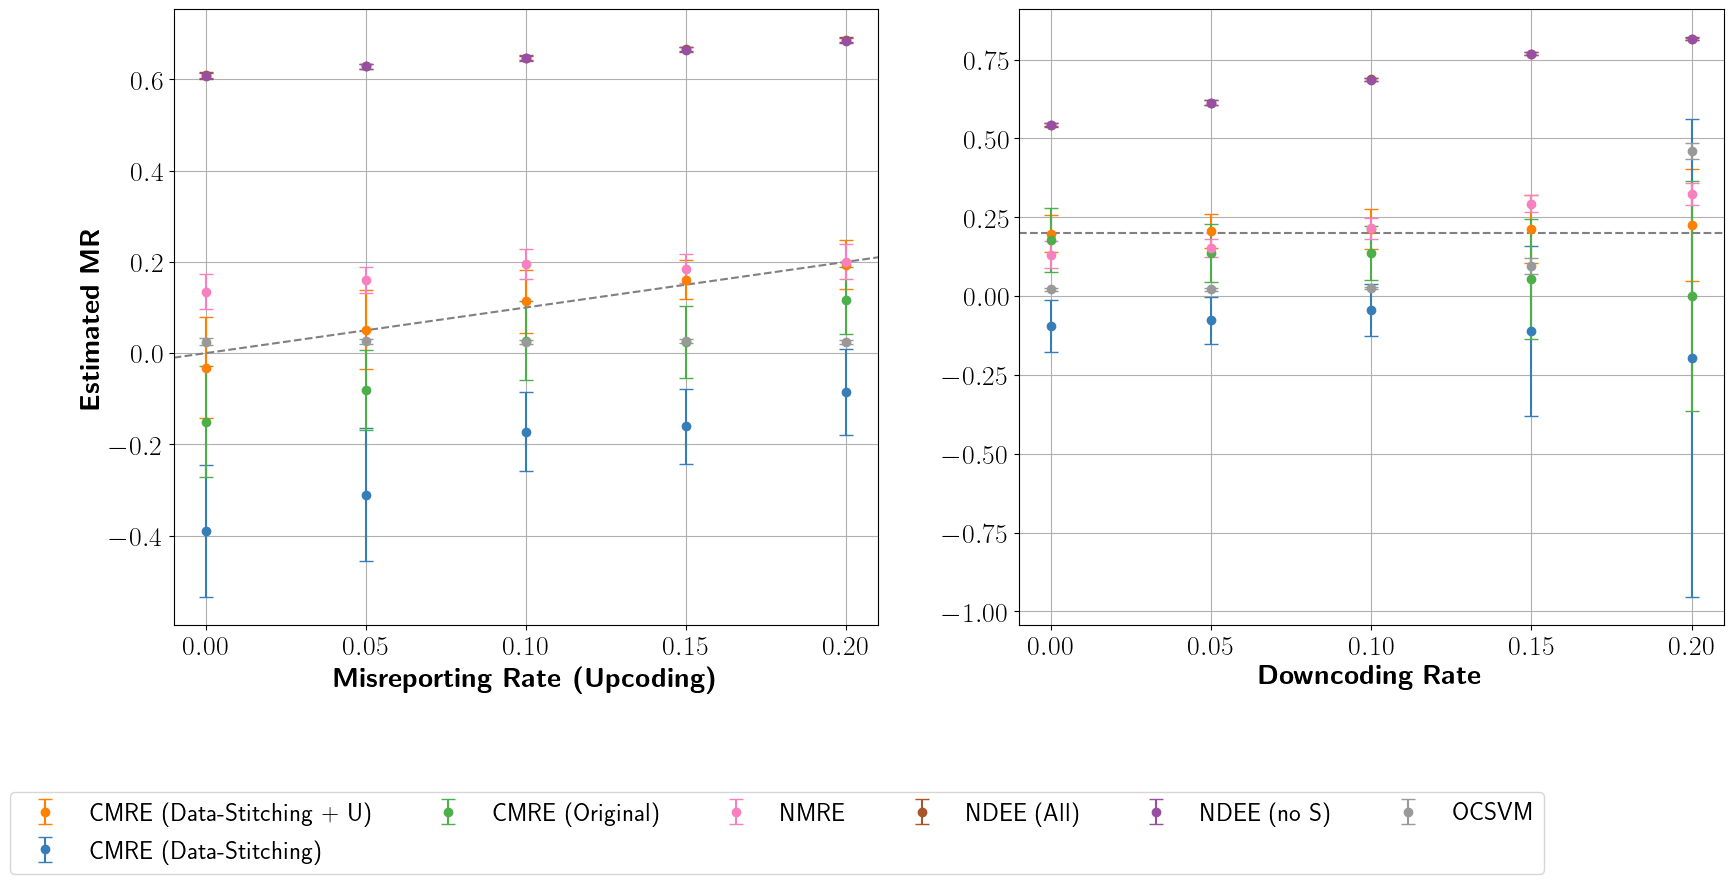

In [24]:
# Create and show plot
synth_list = [loan_list_mr_normal, loan_list_dr_normal] #[loan_list_sa_normal, loan_list_ce_normal, loan_list_mr_normal, loan_list_dr_normal]
synth_mr_list =  [0.2, 0.2] #[0.2, 0.2, 0.2, 0.2]
label_list = ['CMRE (Data-Stitching + U)', 'CMRE (Data-Stitching)', 'CMRE (Original)', 'NMRE', 'NDEE (All)', 'NDEE (no S)', 'OCSVM']
x_var_list = ['true_mr', 'true_dr'] #['sa', 'ce', 'true_mr', 'true_dr']
x_label_list = [r'\textbf{Misreporting Rate (Upcoding)}', r'\textbf{Downcoding Rate}']
y_label = r'\textbf{Estimated MR}'

plt = plot_appendix(synth_list,
                label_list,
                synth_mr_list,
                x_var_list,
                x_label_list,
                y_label)


# plt.show()
plt.savefig(f'{RESULTS_DIR}/simulation_7_appendix_plot_2.pdf', dpi=600, bbox_inches='tight')

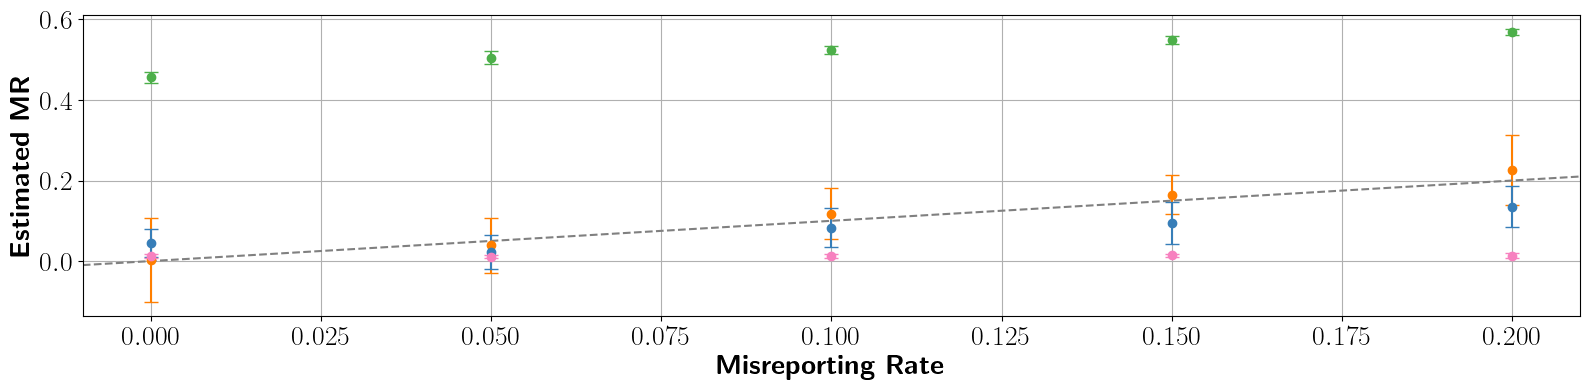

In [ ]:
# # Create and show plot
# indices = [0,1,2,4]
# # loan_list_sa_normal_small = [loan_list_sa_normal[i] for i in indices]
# # loan_list_ce_normal_small = [loan_list_ce_normal[i] for i in indices]
# loan_list_mr_normal_small = [loan_list_mr_normal[i] for i in indices]
# synth_list = [loan_list_mr_normal_small] # [loan_list_sa_normal_small, loan_list_ce_normal_small, loan_list_mr_normal_small]
# synth_mr_list = [0.2] # [0.2, 0.2, 0.2]
# label_list = [r'\textbf{CMRE (Ours)}', r'\textbf{NMRE}', r'\textbf{NDEE}', r'\textbf{OC-SVM}']
# x_var_list = ['true_mr'] # ['sa', 'ce', 'true_mr']
# x_label_list = [r'\textbf{Misreporting Rate}'] # [r'\textbf{Causal Effect of $A$ on $X^{*}$}', r'\textbf{Causal Effect of $X^{*}$ on $Y$}', r'\textbf{Misreporting Rate}']
# y_label = r'\textbf{Estimated MR}'

# plt = plot_main_paper(synth_list,
#                 label_list,
#                 synth_mr_list,
#                 x_var_list,
#                 x_label_list,
#                 y_label)

# plt.savefig(f'{RESULTS_DIR}/simulation_1_main_plot.pdf', dpi=600, bbox_inches='tight')